In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# create sample data
np.random.seed(1)
n = 300

products = {
    "Laptop": ("Electronics", 55000), "Phone": ("Electronics", 25000), "Headphones": ("Electronics", 2500),
    "Chair": ("Furniture", 4500), "Desk": ("Furniture", 9000), "Bookshelf": ("Furniture", 6500),
    "Notebook": ("Stationery", 120), "Pen Set": ("Stationery", 250), "File Folder": ("Stationery", 180),
}
names = np.random.choice(list(products), n)

df = pd.DataFrame({
    "order_id": range(1001, 1001 + n),
    "order_date": pd.to_datetime("2023-01-01") + pd.to_timedelta(np.random.randint(0, 365, n), unit="D"),
    "product": names,
    "category": [products[p][0] for p in names],
    "price": [products[p][1] for p in names],
    "quantity": np.random.randint(1, 6, n),
    "region": np.random.choice(["North", "South", "East", "West"], n),
})
df["sales"] = df["price"] * df["quantity"]

df.loc[np.random.choice(n, 8, replace=False), "region"] = np.nan
df.loc[np.random.choice(n, 5, replace=False), "quantity"] = np.nan
df = pd.concat([df, df.sample(6, random_state=1)], ignore_index=True)

df.to_csv("sales_data.csv", index=False)

In [3]:
df = pd.read_csv("sales_data.csv")
df.head()

,order_id,order_date,product,category,price,quantity,region,sales
0,1001,2023-11-16,Bookshelf,Furniture,6500,1.0,West,6500
1,1002,2023-02-16,File Folder,Stationery,180,4.0,North,720
2,1003,2023-12-27,Bookshelf,Furniture,6500,3.0,East,19500
3,1004,2023-08-06,Laptop,Electronics,55000,2.0,South,110000
4,1005,2023-04-23,Laptop,Electronics,55000,2.0,East,110000


In [4]:
df.shape

(306, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    306 non-null    int64  
 1   order_date  306 non-null    str    
 2   product     306 non-null    str    
 3   category    306 non-null    str    
 4   price       306 non-null    int64  
 5   quantity    301 non-null    float64
 6   region      297 non-null    str    
 7   sales       306 non-null    int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 19.3 KB


In [6]:
df.describe()

,order_id,price,quantity,sales
count,306.000000,306.000000,301.000000,306.000000
mean,1150.650327,11713.300654,2.973422,33318.856209
std,86.078911,17917.018887,1.331399,56283.616185
min,1001.000000,120.000000,1.000000,120.000000
25%,1077.250000,250.000000,2.000000,720.000000
50%,1150.500000,4500.000000,3.000000,10000.000000
75%,1223.750000,9000.000000,4.000000,35125.000000
max,1300.000000,55000.000000,5.000000,275000.000000


In [7]:
df.isnull().sum()

,0
order_id,0
order_date,0
product,0
category,0
price,0
quantity,5
region,9
sales,0


In [8]:
print(df.duplicated().sum())

6


In [9]:
df = df.drop_duplicates()
df["region"] = df["region"].fillna("Unknown")
df["quantity"] = df["quantity"].fillna(df["quantity"].median())
df["order_date"] = pd.to_datetime(df["order_date"])
df["sales"] = df["price"] * df["quantity"]

df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")

print(df.shape)
print(df.isnull().sum().sum())

(300, 10)
0


In [10]:
print("Total Sales   :", df["sales"].sum())
print("Total Orders  :", df["order_id"].nunique())
print("Avg Order     :", round(df["sales"].mean(), 2))
print("Best Product  :", df.groupby("product")["sales"].sum().idxmax())
print("Best Region   :", df.groupby("region")["sales"].sum().idxmax())

Total Sales   : 10038750.0
Total Orders  : 300
Avg Order     : 33462.5
Best Product  : Laptop
Best Region   : East


In [11]:
category_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False)
category_sales

,sales
category,
Electronics,7975000.0
Furniture,2006500.0
Stationery,57250.0


In [12]:
region_sales = df.groupby("region")["sales"].sum().sort_values(ascending=False)
region_sales

,sales
region,
East,2998780.0
West,2405780.0
South,2299630.0
North,2163180.0
Unknown,171380.0


In [13]:
top_products = df.groupby("product")["sales"].sum().sort_values(ascending=False).head(5)
top_products

,sales
product,
Laptop,5610000.0
Phone,2125000.0
Desk,963000.0
Bookshelf,598000.0
Chair,445500.0


In [14]:
monthly_sales = df.groupby("month")["sales"].sum()
monthly_sales

,sales
month,
1,1141060.0
2,432150.0
3,251770.0
4,599970.0
5,889040.0
6,947410.0
7,727470.0
8,1262280.0
9,686800.0


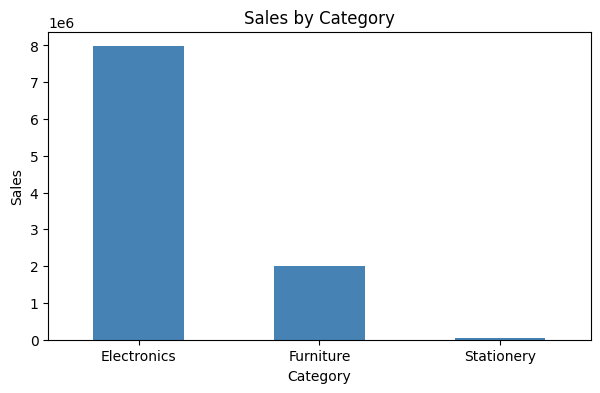

In [15]:
category_sales.plot(kind="bar", color="steelblue", figsize=(7, 4))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

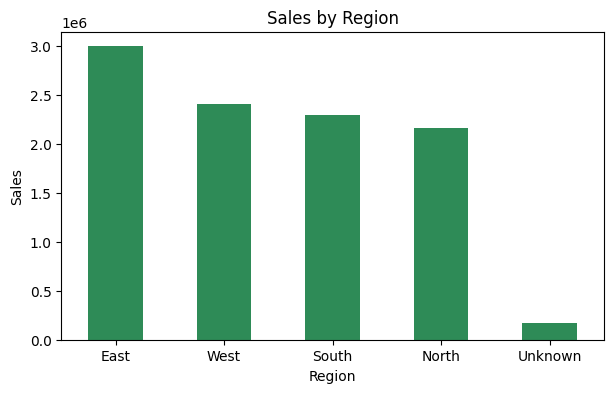

In [16]:
region_sales.plot(kind="bar", color="seagreen", figsize=(7, 4))
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

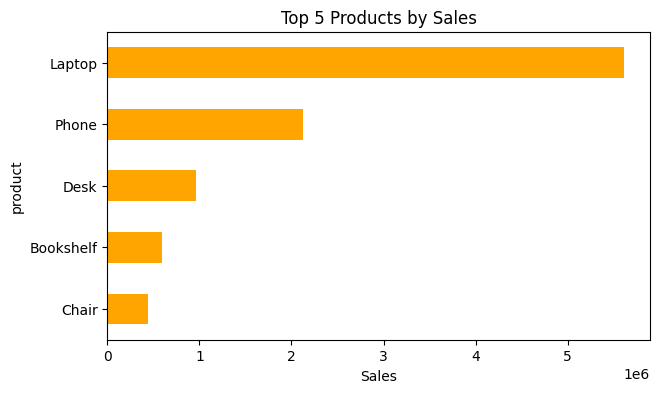

In [17]:
top_products.plot(kind="barh", color="orange", figsize=(7, 4))
plt.title("Top 5 Products by Sales")
plt.xlabel("Sales")
plt.gca().invert_yaxis()
plt.show()

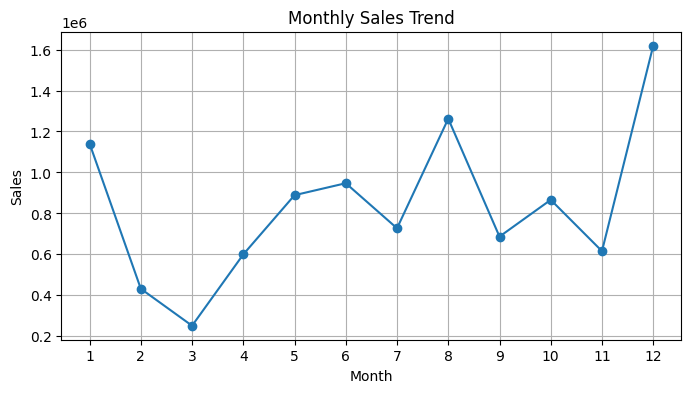

In [18]:
monthly_sales.plot(kind="line", marker="o", figsize=(8, 4))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

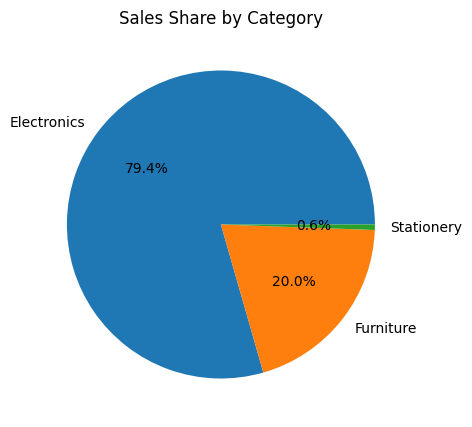

In [19]:
category_sales.plot(kind="pie", autopct="%1.1f%%", figsize=(5, 5))
plt.title("Sales Share by Category")
plt.ylabel("")
plt.show()

In [20]:
pivot = df.pivot_table(values="sales", index="category", columns="region", aggfunc="sum")
pivot

region,East,North,South,Unknown,West
category,,,,,
Electronics,2300000.0,1715000.0,1832500.0,160000.0,1967500.0
Furniture,686000.0,431000.0,455500.0,9000.0,425000.0
Stationery,12780.0,17180.0,11630.0,2380.0,13280.0


In [21]:
df.to_csv("cleaned_sales_data.csv", index=False)
print("Saved cleaned_sales_data.csv")

Saved cleaned_sales_data.csv
